In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import numpy as np
import re

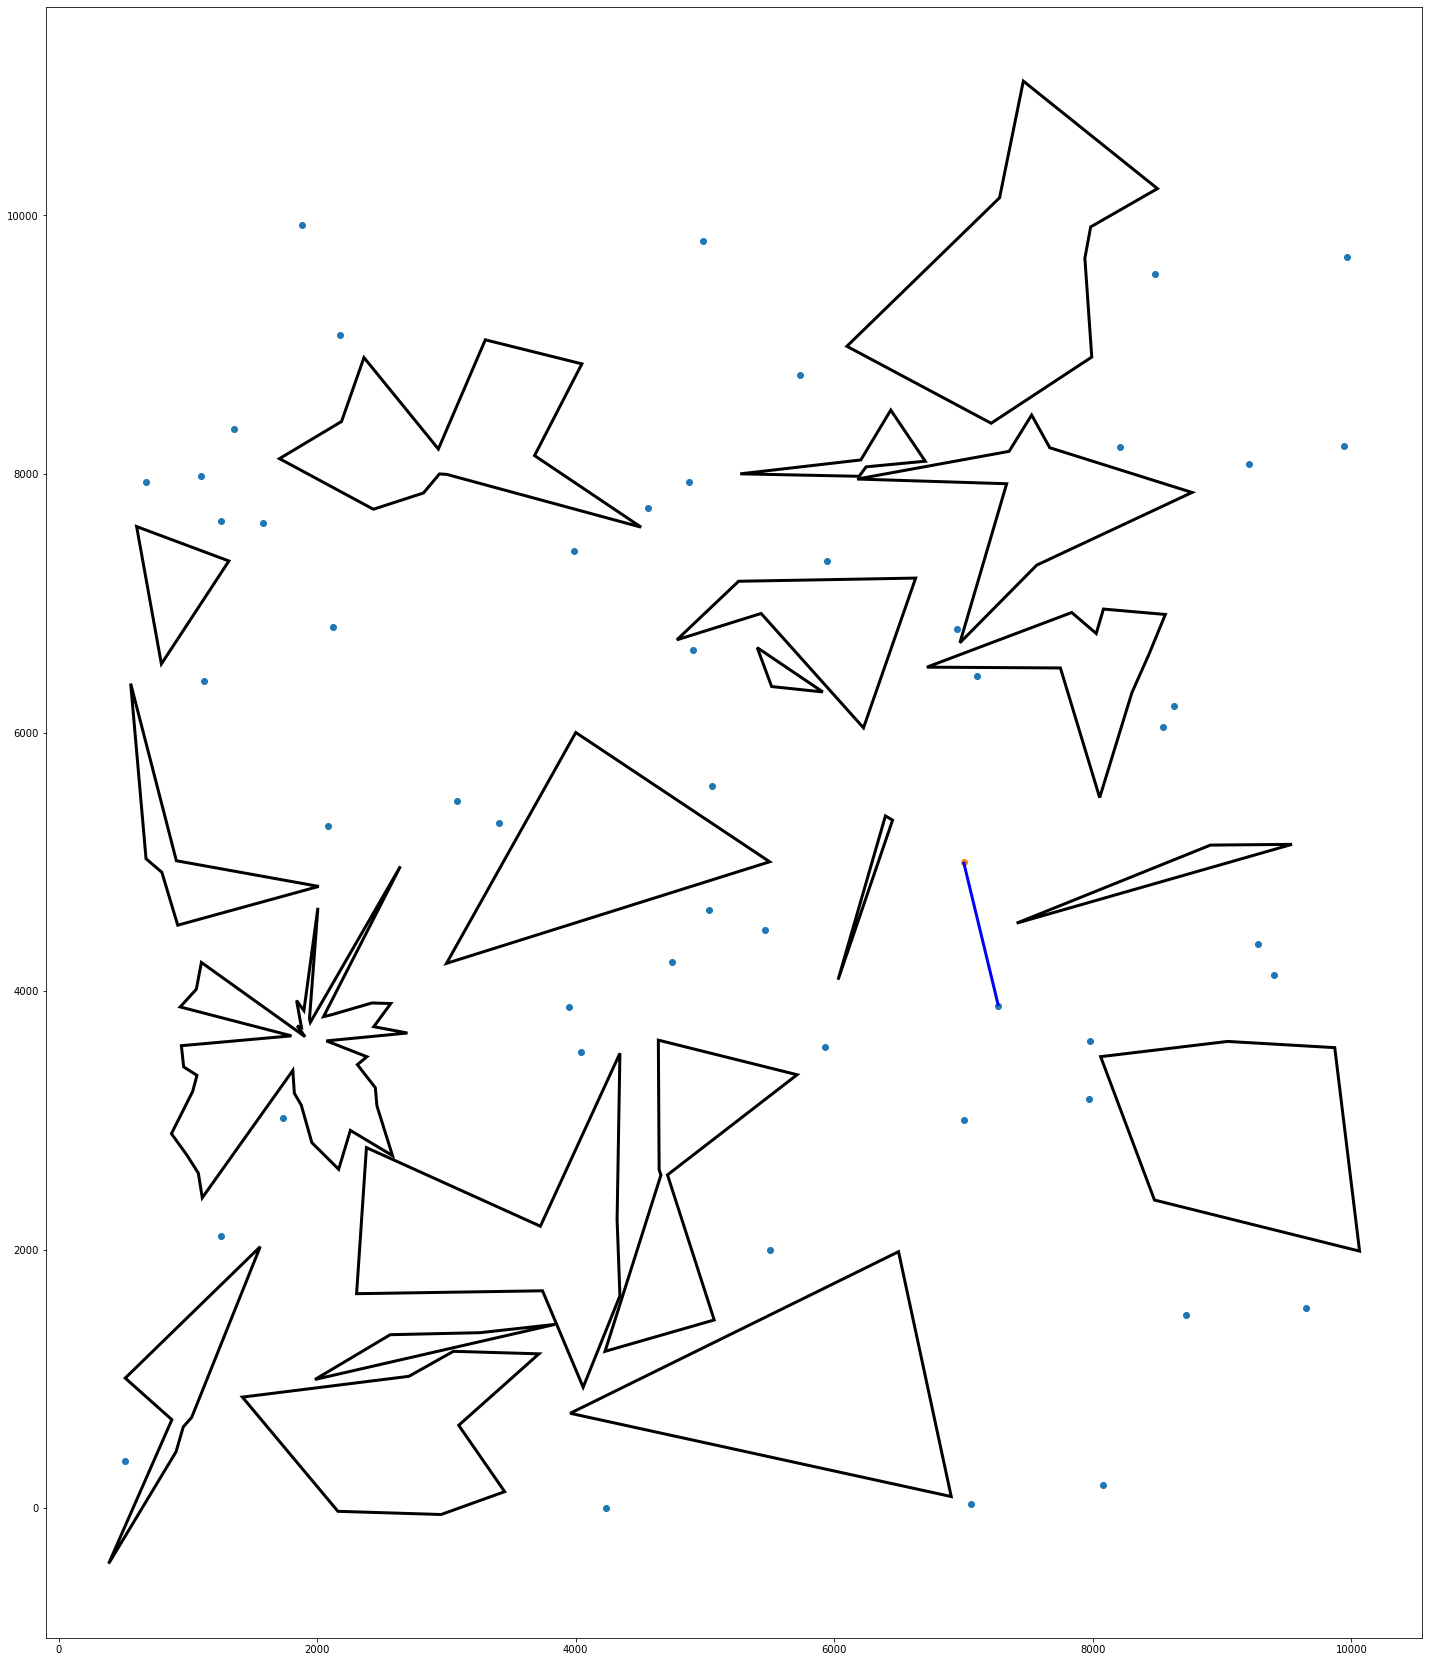

In [14]:
fig, ax = plt.subplots(figsize=(30, 30))

site_list = []
poly_list = []
pth = []

with open('output.txt', mode='r') as output:
    mode = 'b'
    dim = 2
    pattern = re.compile(r'[-+]?(?:\d*\.*\d+)')
    lines = output.readlines()
    index = 0
    xs = []
    ys = []
    
    while index < len(lines):
        n,m = map(int, lines[index].split())
        index += 1
        for i in range(n):
            coord = list(map(float, lines[index+i].split()))
            site_list.append(coord)
            xs.append(coord[0])
            ys.append(coord[1])
        index += n
        for i in range(m):
            k = int(lines[index])
            poly = []
            index += 1
            for j in range(k):
                coord = list(map(float, lines[index+j].split()))
                xs.append(coord[0])
                ys.append(coord[1])
                poly.append(coord)
            poly_list.append(poly)
            index += k
        query = list(map(float,lines[index].split()))
        xs.append(query[0])
        ys.append(query[1])
        index += 1
        l = int(lines[index])
        index += 1
        for i in range(l):
            coord = list(map(float, lines[index+i].split()))
            xs.append(coord[0])
            ys.append(coord[1])
            pth.append(coord)
        index += l

X=np.array([min(xs),max(xs)])
Y=np.array([min(ys),max(ys)])
plt.plot(X,Y,color='None')
x_list, y_list = zip(*site_list)
plt.scatter(x_list,y_list)
plt.scatter(query[0],query[1])
for poly in poly_list:
    shp=patches.Polygon(np.array(poly), fill=None ,edgecolor='k',ls='solid',lw=3)
    plt.gca().add_patch(shp)
path = Path(pth)
shp = patches.PathPatch(path, fill=None, edgecolor='b', ls='solid', lw=3)
plt.gca().add_patch(shp)
plt.axis('scaled')
plt.show()